# Scenario 02 — Session Resumption

Fresh handshake vs resumed handshake, classical (X25519) vs hybrid PQ (X25519MLKEM768).

**Hypothesis**: resumption collapses the gap between classical and PQ to near-zero, because the KEX material is skipped on resume. We're trying to show real-world traffic (which overwhelmingly resumes) sees ~none of the PQ overhead observed in Phase 1.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
import sys

sys.path.insert(0, '.')
from parse_gatling import collect_results, summarize

In [2]:
# EDIT THIS to your results directory (printed at end of run.sh)
RESULTS = "../results/2026-10-03-scenario-02-rate300"

df = collect_results(RESULTS)
df

,arm,trial,req_total,req_ok,req_ko,pct_ko,rps_mean,min_ms,p50_ms,p75_ms,...,request_name,tls_group,mode,sim_class,rate_users_per_sec,requests_per_user,measure_sec,warmup_sec,target_private_ip,timestamp_utc
0,classical-fresh,1,90000.0,90000.0,0.0,0.0,268.66,1.0,1.0,2.0,...,fresh_hs,X25519,fresh,pqcbench.FreshHandshakeLatency,300,10,300,30,10.99.1.133,2026-10-03T12:09:57Z
1,classical-fresh,2,90000.0,90000.0,0.0,0.0,268.66,1.0,1.0,2.0,...,fresh_hs,X25519,fresh,pqcbench.FreshHandshakeLatency,300,10,300,30,10.99.1.133,2026-10-03T12:16:52Z
2,classical-fresh,3,90000.0,90000.0,0.0,0.0,268.66,1.0,1.0,2.0,...,fresh_hs,X25519,fresh,pqcbench.FreshHandshakeLatency,300,10,300,30,10.99.1.133,2026-10-03T12:23:48Z
3,classical-resumed,1,900000.0,900000.0,0.0,0.0,2686.57,0.0,0.0,0.0,...,resumed_req,X25519,resumed,pqcbench.ResumedHandshake,300,10,300,30,10.99.1.133,2026-10-03T12:32:50Z
4,classical-resumed,2,900000.0,900000.0,0.0,0.0,2686.57,0.0,0.0,0.0,...,resumed_req,X25519,resumed,pqcbench.ResumedHandshake,300,10,300,30,10.99.1.133,2026-10-03T12:41:28Z
5,classical-resumed,3,900000.0,900000.0,0.0,0.0,2686.57,0.0,0.0,0.0,...,resumed_req,X25519,resumed,pqcbench.ResumedHandshake,300,10,300,30,10.99.1.133,2026-10-03T12:50:01Z
6,pq-fresh,1,90000.0,90000.0,0.0,0.0,268.66,1.0,2.0,2.0,...,fresh_hs,X25519MLKEM768,fresh,pqcbench.FreshHandshakeLatency,300,10,300,30,10.99.1.234,2026-10-03T12:59:03Z
7,pq-fresh,2,90000.0,90000.0,0.0,0.0,268.66,1.0,1.0,2.0,...,fresh_hs,X25519MLKEM768,fresh,pqcbench.FreshHandshakeLatency,300,10,300,30,10.99.1.234,2026-10-03T13:06:06Z
8,pq-fresh,3,90000.0,90000.0,0.0,0.0,268.66,1.0,1.0,2.0,...,fresh_hs,X25519MLKEM768,fresh,pqcbench.FreshHandshakeLatency,300,10,300,30,10.99.1.234,2026-10-03T13:13:21Z
9,pq-resumed,1,900000.0,900000.0,0.0,0.0,2686.57,0.0,0.0,0.0,...,resumed_req,X25519MLKEM768,resumed,pqcbench.ResumedHandshake,300,10,300,30,10.99.1.234,2026-10-03T13:22:01Z


## Per-arm summary (mean ± std across trials)

In [3]:
summ = summarize(df)
summ

mean_ms      p50_ms       p75_ms      p95_ms      p99_ms  \
                     mean  std   mean   std   mean  std   mean  std   mean   
arm                                                                          
classical-fresh       2.0  0.0   1.00  0.00    2.0  0.0    4.0  0.0  11.00   
classical-resumed     0.0  0.0   0.00  0.00    0.0  0.0    1.0  0.0   1.00   
pq-fresh              2.0  0.0   1.33  0.58    2.0  0.0    5.0  0.0   6.33   
pq-resumed            0.0  0.0   0.00  0.00    0.0  0.0    1.0  0.0   1.00   

                        max_ms         
                    std   mean    std  
arm                                    
classical-fresh    8.66  50.33  13.32  
classical-resumed  0.00   7.00   1.00  
pq-fresh           0.58  54.67   4.16  
pq-resumed         0.00   6.33   0.58

## Fresh vs resumed, side by side

The spread between classical-fresh and pq-fresh is what Phase 1 measured.
The spread between classical-resumed and pq-resumed is what the Phase 2 pitch rests on.

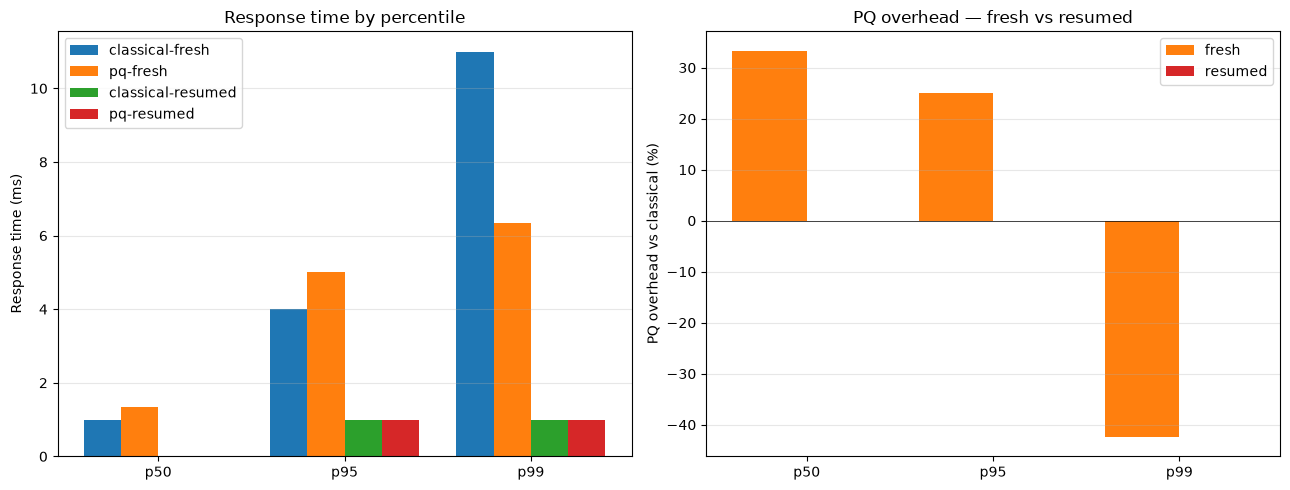

Fresh overhead: {'p50_ms': 33.3, 'p95_ms': 25.0, 'p99_ms': -42.4}
Resumed overhead: {'p50_ms': nan, 'p95_ms': 0.0, 'p99_ms': 0.0}


In [4]:
ARM_ORDER = ["classical-fresh", "pq-fresh", "classical-resumed", "pq-resumed"]
COLORS = {"classical-fresh": "#1f77b4", "pq-fresh": "#ff7f0e",
         "classical-resumed": "#2ca02c", "pq-resumed": "#d62728"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Mean across trials for each arm × percentile
agg = df.groupby("arm")[["p50_ms", "p95_ms", "p99_ms"]].mean().reindex(ARM_ORDER)

x = np.arange(3)
width = 0.2
for i, arm in enumerate(ARM_ORDER):
    if arm not in agg.index:
        continue
    axes[0].bar(x + i * width, agg.loc[arm], width, label=arm, color=COLORS[arm])
axes[0].set_xticks(x + 1.5 * width)
axes[0].set_xticklabels(["p50", "p95", "p99"])
axes[0].set_ylabel("Response time (ms)")
axes[0].set_title("Response time by percentile")
axes[0].legend()
axes[0].grid(True, axis="y", alpha=0.3)

# PQ overhead %: (pq - classical) / classical
fresh_overhead  = (agg.loc["pq-fresh"]    - agg.loc["classical-fresh"])   / agg.loc["classical-fresh"]   * 100
resumed_overhead = (agg.loc["pq-resumed"] - agg.loc["classical-resumed"]) / agg.loc["classical-resumed"] * 100

x2 = np.arange(3)
axes[1].bar(x2 - 0.2, fresh_overhead,   0.4, label="fresh",   color="#ff7f0e")
axes[1].bar(x2 + 0.2, resumed_overhead, 0.4, label="resumed", color="#d62728")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(["p50", "p95", "p99"])
axes[1].set_ylabel("PQ overhead vs classical (%)")
axes[1].set_title("PQ overhead — fresh vs resumed")
axes[1].axhline(0, color="k", linewidth=0.5)
axes[1].legend()
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("02-resumption-overhead.png", dpi=150, bbox_inches="tight")
plt.show()

print("Fresh overhead:",  fresh_overhead.round(1).to_dict())
print("Resumed overhead:", resumed_overhead.round(1).to_dict())

## Narrative numbers for the blog post

In [5]:
p95 = df.groupby("arm")["p95_ms"].mean()
print(f"""
Fresh handshake — PQ adds   {p95['pq-fresh']  - p95['classical-fresh']:+.2f} ms at p95 ({(p95['pq-fresh']/p95['classical-fresh']-1)*100:+.1f}%)
Resumed       — PQ adds   {p95['pq-resumed'] - p95['classical-resumed']:+.2f} ms at p95 ({(p95['pq-resumed']/p95['classical-resumed']-1)*100:+.1f}%)

Resumption's gain vs fresh:
  classical: {p95['classical-fresh'] - p95['classical-resumed']:.2f} ms faster at p95
  pq:        {p95['pq-fresh'] - p95['pq-resumed']:.2f} ms faster at p95
""")


Fresh handshake — PQ adds   +1.00 ms at p95 (+25.0%)
Resumed       — PQ adds   +0.00 ms at p95 (+0.0%)

Resumption's gain vs fresh:
  classical: 3.00 ms faster at p95
  pq:        4.00 ms faster at p95

